# Relative Vorticity

This notebook shows a simple example of calculation the vertical component of relative vorticity, but is applicable to any curl calculation as well. Relative vorticity is defined as the curl of the velocity field:

$$\zeta = \partial_x v - \partial_y u.$$

For demonstration purposes we will compute the vorticity near the surface, but the method can be applied to any depth.

We will demonstrate three methods for computing relative vorticity:

1. A naïve method of simply converting degrees of longitude/latitude into metres and differentiating.
2. A different method that tries to replicate the way the model computes relative vorticity.
3. A simpler but accurate method leveraging the functionality of `xgcm`. **This is the recommended method**.

**Caveat: Both methods 2 and 3 automatically extend land masks into the domain, so needs extreme care if you care about coastlines!** see https://github.com/xgcm/xgcm/issues/324

---

This recipe is intended to work with output from ACCESS-OM2, where MOM5 uses an Arakawa B-grid and velocities are given at cell corners. For adaptation to MOM6, which uses an Arakawa C-grid, you should take into account that velocities are in cell faces. This means that:

| MOM5 diagnostic (x-coord, y-coord) | MOM6 diagnostic (x-coord, y-coord) |
| --- | --- |
| `u (xu_ocean, yu_ocean)`  | `uo (xq, yh)` |
| `v (xu_ocean, yu_ocean)`  | `vo (xh, yq)` |
| `vorticity_z (xt_ocean, yt_ocean)`  | `RV (xq, yq)` |

Most experiments will also have four different options of $dx$ and $dy$ to account for distances in different grids/faces. We recommend you approach the calculation using Method 3, and adapt the interpolation and differentiation steps to suit MOM6 diagnostics.

Load in the requisite libraries:

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client

Load a `dask` client.

In [2]:
client = Client(threads_per_worker=1, memory_limit=0)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33941,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34359,Total threads: 1
Dashboard: /proxy/34669/status,Memory: 0 B
Nanny: tcp://127.0.0.1:38953,


Open the ACCESS-NRI default catalog and the first cycle of the 0.1$^{\circ}$ IAF experiment. This recipe uses this experiment because it has velocity and vorticity diagnostics available at the same time step. This will allow us to compare methods. 

In [3]:
catalog = intake.cat.access_nri

In [4]:
experiment = "01deg_jra55v140_iaf"

Load the diagnostics needed for this recipe - note that `intake` is not able, currently, to load `to_dask` datasets in different grids, so we will load them separately.

We will load grid diagnostics (distances in meridional and zonal directions, as well as latitude, longitude), one day of velocities at a certain depth level, and MOM5's relative vorticity diagnostic, which we will use to compare the three methods.

In [5]:
geolon_c = catalog[experiment].search(variable=['geolon_c'],
                                      frequency="fx").to_dask()['geolon_c']
geolon_c = geolon_c.sel(xu_ocean=slice(-90,-40), yu_ocean=slice(20,60))
geolat_c = catalog[experiment].search(variable=['geolat_c'],
                                      frequency="fx").to_dask()['geolat_c']
geolat_c = geolat_c.sel(xu_ocean=slice(-90,-40), yu_ocean=slice(20,60))

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='geolon_c' → variable=['geolon_c','geolon_c']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='geolat_c' → variable=['geolat_c','geolat_c']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)


In [6]:
# u-grid diagnostics
dxu = catalog["01deg_jra55v140_iaf"].search(variable=["dxu"], 
                                            frequency="fx").to_dask().sel(xu_ocean=slice(-90,-40), yu_ocean=slice(20,60))
dyu = catalog["01deg_jra55v140_iaf"].search(variable=["dyu"], 
                                            frequency="fx").to_dask().sel(xu_ocean=slice(-90,-40), yu_ocean=slice(20,60))

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='dxu' → variable=['dxu','dxu']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='dyu' → variable=['dyu','dyu']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordina

In [7]:
# u-grid diagnostics
dxt = catalog["01deg_jra55v140_iaf"].search(variable=["dxt"], 
                                            frequency="fx").to_dask().sel(xt_ocean=slice(-90,-40), yt_ocean=slice(20,60))
dyt = catalog["01deg_jra55v140_iaf"].search(variable=["dyt"], 
                                            frequency="fx").to_dask().sel(xt_ocean=slice(-90,-40), yt_ocean=slice(20,60))

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='dxt' → variable=['dxt','dxt']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='dyt' → variable=['dyt','dyt']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordina

In [8]:
# Load velocity as monthly snapshots (indicated by the variable cell methods argument)
velocity_diagnostics = ["u","v"]
depth_level = 30
def subset(ds):
    ds = ds.sel(xu_ocean=slice(-90,-40), yu_ocean=slice(20,60)).sel(st_ocean=depth_level, method='nearest')
    return ds
ds_velocity = catalog[experiment].search(variable=velocity_diagnostics, 
                                         frequency="1mon", 
                                         variable_cell_methods='time: point'
                                         ).to_dask(preprocess=subset)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='u' → variable=['u','u']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='v' → variable=['v','v']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:305: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  self._ds = xr.combine_by_coords(


In [9]:
# Load vorticity as monthly snapshots (indicated by the variable cell methods argument)
vorticity_diagnostics = ["vorticity_z"]
depth_level = 30
def subset(ds):
    ds = ds.sel(xt_ocean=slice(-90,-40), yt_ocean=slice(20,60)).sel(st_ocean=depth_level, method='nearest')
    return ds
ds_vorticity = catalog[experiment].unwrap().search(variable=vorticity_diagnostics, 
                                                 frequency="1mon", 
                                                 variable_cell_methods='time: point'
                                                 ).to_dask(preprocess=subset)

In [10]:
# Combine all we need in the same dataset and select a random time step
ds = xr.merge([ds_velocity, ds_vorticity, dxu, dyu, dxt, dyt], compat='override')
ds = ds.isel(time=-1)

## Method 1 (naïve computation)

To compute relative vorticity $\zeta = \partial_x v - \partial_y u$ we simply differentiate the velocity components with respect of `lon` (here `xu_ocean` in degrees) and `lat` (here `yu_ocean` in degrees). We then convert the derivatives from units of degrees$^{-1}$ to m$^{-1}$. To do so, we use the value of the radius of the Earth `Rearth` and also take into account that as we go towards the poles the `lon`-grid spacing is scaled by $\cos($ `lat` $)$.

(Note the unicode characters like `ζ` can be used in `python`.)

In [11]:
# values used by MOM5
Ω = 7.292e-5  # Earth's rotation rate; in radians/s
Rearth = 6371e3  # Earth's radius; in m

Calculate the Coriolis parameter $f = 2\Omega \sin(\texttt{lat})$.

In [12]:
f = 2 * Ω * np.sin(np.deg2rad(geolat_c))  # convert lat in radians
f = f.rename("Coriolis")
f.attrs["long_name"] = "Coriolis parameter"
f.attrs["units"] = "s-1"
f.attrs["coordinates"] = "geolon_c geolat_c"

Now we can calculate relative vorticity:

In [13]:
dx = np.deg2rad(Rearth * np.cos(np.deg2rad(geolat_c)))
dy = (np.pi / 180 * Rearth)
ζ_naive = ds["v"].differentiate("xu_ocean") / dx - ds["u"].differentiate("yu_ocean") / dy
ζ_naive = ζ_naive.rename("Relative Vorticity").drop_vars('geolat_c')
ζ_naive.attrs["long_name"] = "Relative Vorticity, ∂v/∂x-∂u/∂y"
ζ_naive.attrs["units"] = "s-1"

In [14]:
ζ_naive

<xarray.DataArray 'Relative Vorticity' (yu_ocean: 550, xu_ocean: 500)> Size: 1MB
dask.array<sub, shape=(550, 500), dtype=float32, chunksize=(270, 260), chunktype=numpy.ndarray>
Coordinates:
  * yu_ocean  (yu_ocean) float64 4kB 20.08 20.17 20.26 ... 59.87 59.92 59.97
  * xu_ocean  (xu_ocean) float64 4kB -89.9 -89.8 -89.7 ... -40.2 -40.1 -40.0
    st_ocean  float64 8B 29.45
    time      datetime64[ns] 8B 2019-01-01
Attributes:
    long_name:     Relative Vorticity, ∂v/∂x-∂u/∂y
    units:         s-1
    valid_range:   [-91.  91.]
    cell_methods:  time: point

We now plot $\zeta$ in the North Atlantic.

In [15]:
maxvalue = 5e-5
levels = np.linspace(-maxvalue, maxvalue, 24)

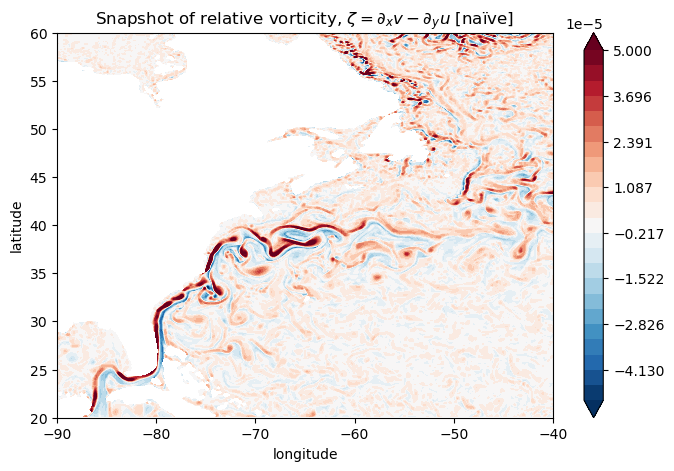

In [16]:
plt.figure(figsize=(8, 5))

plt.contourf(geolon_c, 
             geolat_c, 
             ζ_naive, 
             levels=levels,
             cmap='RdBu_r',
             extend='both')
plt.colorbar()

plt.title(
    "Snapshot of relative vorticity, $\zeta = \partial_x v - \partial_y u$ [naïve]"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.xlim(-90, -40)
plt.ylim(20, 60);

**Caveat**: this method is sort-of-OK below 65$^{\circ}$N where the complications of the tripolar grid do not enter. But even south of 65N this method gives a rough estimate. 

It's OK for visualising but it should **not** be used in computing, e.g., vorticity budgets.

## Method 2: replicating how MOM5 computes `vorticity_z`

MOM5's relative vorticity diagnostic is called `vorticity_z`. Looking at [MOM5 code](https://github.com/mom-ocean/MOM5/blob/64990e1de853a175335848b67b580363053a79b4/src/mom5/ocean_diag/ocean_velocity_diag.F90#L1172-L1183) and by doing some translation from Fortran code to "english" we can see that the models computes `vorticity_z` via:

$$ \zeta(i, j, k) = \frac1{2}\Big[ \underbrace{ \frac{v(i,j,k) - v(i-1,j,k)}{\Delta x_{N}(i,j,k)} }_{\approx \partial_x v(i,j,k)} +  \underbrace{\frac{v(i,j-1,k) - v(i-1,j-1,k)}{\Delta x_{N}(i,j-1,k)}}_{\approx \partial_x v(i,j-1,k)} \Big] \\
\qquad \qquad \qquad -  \frac1{2}\Big[ \underbrace{ \frac{u(i,j,k) - u(i,j-1,k)}{\Delta y_{E}(i,j,k)} }_{\approx \partial_y u(i,j,k)} +  \underbrace{\frac{u(i-1,j,k) - u(i-1,j-1,k)}{\Delta y_{E}(i-1,j,k)}}_{\approx \partial_y u(i,j-1,k)} \Big].$$

Above, $(i, j, k)$ refers to the grid-point indices for directions $x, y, z$ respectively. 

The distances $\Delta x_N$ and $\Delta y_E$ correspond to the North and East faces of the corresponding $T$-cell; see the diagram below. (T-points are those in the cells's centres where tracers are evaluated and U-points are in the cells's corners where velocities are evaluated.)

![](images/Bgrid.png)

After a lot of fiddling with the indices you can confirm that the right way to compute $\delta x_N$ and $\delta y_E$ from above is:

In [17]:
inverse_dxtn = 0.5 * (1 / ds.dxu + np.roll(1 / ds.dxu, 1, axis=1))
inverse_dyte = 0.5 * (1 / ds.dyu + np.roll(1 / ds.dyu, 1, axis=0))

... and with that we can now compute `ζ_mom5` which is the vorticity as exactly the way is computed by the model:

In [18]:
vx_ijk = (ds.v - np.roll(ds.v, 1, axis=1)) * inverse_dxtn
uy_ijk = (ds.u - np.roll(ds.u, 1, axis=0)) * inverse_dyte

vx = 0.5 * (vx_ijk + np.roll(vx_ijk, 1, axis=0))
uy = 0.5 * (uy_ijk + np.roll(uy_ijk, 1, axis=1))

ζ_mom5 = vx - uy

The way we computed `ζ_mom5` above using `numpy.roll` is not really ideal. One would like to do the above using `xarray`'s functionality... But, as we will argue below, you shouldn't be using this way anyway because it's cumbersome and it requires you to know the specifics of the staggered grid used in the model (Arakawa B-grid for MOM5). A way to avoid getting into the nitty-gritty of staggered grids is to use `xgcm` packaged (described in **Method 3**).

With this and that let's plot `ζ_mom5`.

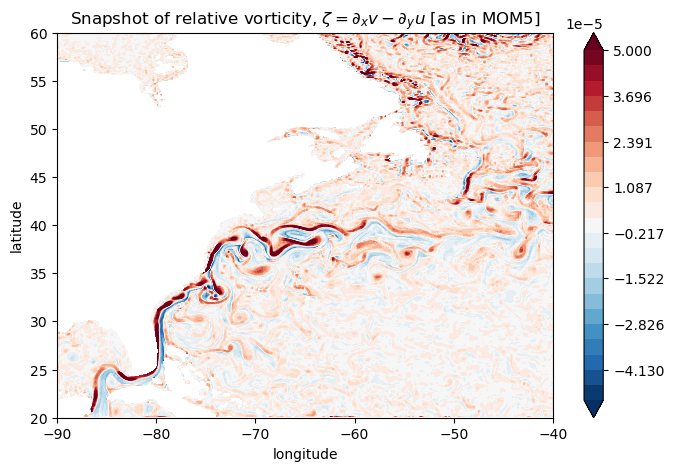

In [19]:
plt.figure(figsize=(8, 5))

plt.contourf(geolon_c, 
             geolat_c, 
             ζ_mom5, 
             levels=levels,
             cmap='RdBu_r',
             extend='both')
plt.colorbar()

plt.title(
    "Snapshot of relative vorticity, $\zeta = \partial_x v - \partial_y u$ [as in MOM5]"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.xlim(-90, -40)
plt.ylim(20, 60);

## Method 3: Using `xgcm`

[`xgcm`](https://xgcm.readthedocs.io/en/stable/) is a package that deals with staggered grids that are typically used in ocean models. An excerpt from `xgcm`'s docs mentions:

> "(in model output datasets), different variables are located at different positions with respect to a volume or area element (e.g. cell center, cell face, etc.) xgcm solves the problem of how to interpolate and difference these variables from one position to another."

In [20]:
import xgcm

We first need to create a `grid` object that has all the information regarding our staggered grid. For our case, `grid` needs to know the location of the `xt_ocean`, `xu_ocean` points (and same for $y$) and their relative orientation to one another, i.e., that `xu_ocean` is shifted to the right of `xt_ocean` by $\frac1{2}$ grid-cell.

`xgcm` also expects you to pass on grid information in which `xt_ocean`, `xu_ocean` are of the same length and staggered in the correct direction (`u` to the right of `t`) - and same for the y-direction. Lets check that.

In [21]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:      (yu_ocean: 550, xu_ocean: 500, yt_ocean: 551, xt_ocean: 500)
Coordinates:
  * yu_ocean     (yu_ocean) float64 4kB 20.08 20.17 20.26 ... 59.87 59.92 59.97
  * xu_ocean     (xu_ocean) float64 4kB -89.9 -89.8 -89.7 ... -40.2 -40.1 -40.0
  * yt_ocean     (yt_ocean) float64 4kB 20.03 20.12 20.22 ... 59.9 59.95 60.0
  * xt_ocean     (xt_ocean) float64 4kB -89.95 -89.85 -89.75 ... -40.15 -40.05
    st_ocean     float64 8B 29.45
    time         datetime64[ns] 8B 2019-01-01
Data variables:
    u            (yu_ocean, xu_ocean) float32 1MB dask.array<chunksize=(171, 260), meta=np.ndarray>
    v            (yu_ocean, xu_ocean) float32 1MB dask.array<chunksize=(171, 260), meta=np.ndarray>
    vorticity_z  (yt_ocean, xt_ocean) float32 1MB dask.array<chunksize=(171, 260), meta=np.ndarray>
    dxu          (yu_ocean, xu_ocean) float32 1MB dask.array<chunksize=(550, 500), meta=np.ndarray>
    dyu          (yu_ocean, xu_ocean) float32 1MB dask.array<chunksize=(550, 500), meta=np.ndarray>
    dxt          (yt_ocean, xt_ocean) float32 1MB dask.array<chunksize=(551, 500), meta=np.ndarray>
    dyt          (yt_ocean, xt_ocean) float32 1MB dask.array<chunksize=(551, 500), meta=np.ndarray>
Attributes:
    title:                                   ACCESS-OM2-01
    grid_type:                               mosaic
    grid_tile:                               1
    intake_esm_attrs:file_id:                ocean.1mon.st_edges_ocean:76.st_...
    intake_esm_attrs:frequency:              1mon
    intake_esm_attrs:variable_cell_methods:  ,,,time: point,,
    intake_esm_attrs:variable_units:         meters,meters,days since 1900-01...
    intake_esm_attrs:realm:                  ocean
    intake_esm_attrs:temporal_label:         point
    intake_esm_attrs:_data_format_:          netcdf
    intake_esm_dataset_key:                  ocean.1mon.st_edges_ocean:76.st_...

The x-direction is correct, but in the y-direction we need to remove the last t-point:

In [22]:
ds = ds.isel(yt_ocean=slice(None,-1))

In [23]:
ds.coords["xt_ocean"].attrs.update(axis="X")
ds.coords["xu_ocean"].attrs.update(axis="X", c_grid_axis_shift=0.5)
ds.coords["yt_ocean"].attrs.update(axis="Y")
ds.coords["yu_ocean"].attrs.update(axis="Y", c_grid_axis_shift=0.5)

grid = xgcm.Grid(ds)

We can use this `grid` object to interpolate diagnostics across grids - for example, `grid.interp(v, 'Y')` will bring `v` from `yu_ocean` to `yt_ocean`. 

We can also compute differences using the `.diff` function. For example, the expression $v(i,j,k) - v(i-1,j,k)$ is obtained via `grid.diff(v, 'X')` - note that the result will also shift `v` from `xu_ocean` to `xt_ocean`. 

**An important caveat** to keep in mind is that because the grids are curvilinear, you must be cautious when interpolating `dx` in the meridional direction. In fact, it is best to avoid doing that and use `dxu` or `dxt` without interpolating.

Using `xgcm`'s functionality we can replicate the MOM5 vertical vorticity computation as:

In [24]:
vx = grid.diff(ds["v"], "X", boundary="extend")
# Interpolate to t-cells and divide by dxt
vx = grid.interp(vx, "Y", boundary="extend") / ds["dxt"]

uy = grid.diff(ds["u"], "Y", boundary="extend")
# Interpolate to t-cells and divide by dxt
uy = grid.interp(uy, "X", boundary="extend") / ds["dyt"]

ζ_xgcm = vx - uy

ζ_xgcm = ζ_xgcm.rename("Relative Vorticity")
ζ_xgcm.attrs["long_name"] = "Relative Vorticity, ∂v/∂x-∂u/∂y"
ζ_xgcm.attrs["units"] = "s-1"

Now, let's plot `ζ_xgcm`:

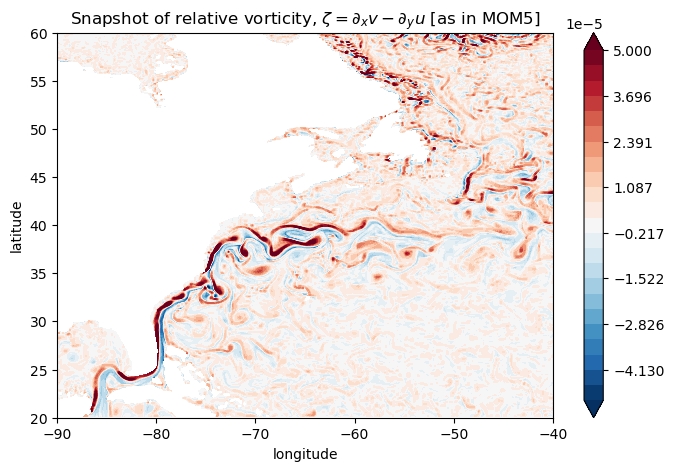

In [25]:
plt.figure(figsize=(8, 5))

plt.contourf(geolon_c, 
             geolat_c, 
             ζ_xgcm, 
             levels=levels,
             cmap='RdBu_r',
             extend='both')
plt.colorbar()

plt.title(
    "Snapshot of relative vorticity, $\zeta = \partial_x v - \partial_y u$ [as in MOM5]"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.xlim(-90, -40)
plt.ylim(20, 60);

## Comparison of the three methods

Now we can see how each method compares to the MOM5 relative vorticity diagnostic:

In [26]:
maxvalue = 5e-6

The calculation from Method 1 and 2 must be interpolated to the t-grid to be able to compare with `vorticity_z`:

In [29]:
ζ_naive_t = grid.interp(ζ_naive, ["X","Y"], boundary="extend")
ζ_mom5_t = grid.interp(ζ_mom5, ["X","Y"], boundary="extend")

Now we can plot the differences:

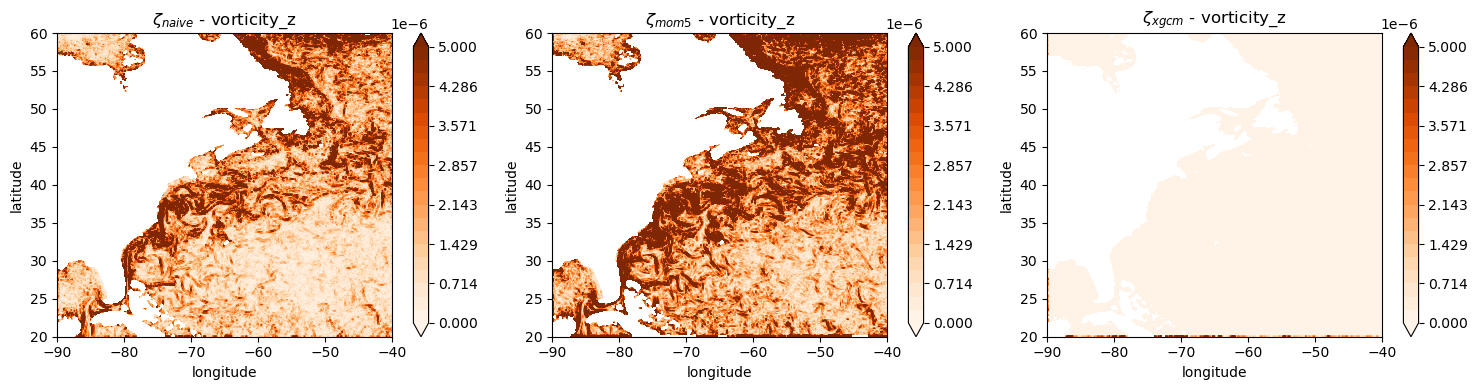

In [32]:
fig, axs = plt.subplots(1,3,figsize=(15, 4))

c=axs[0].contourf(geolon_c, 
                geolat_c, 
                np.abs(ζ_naive_t - ds['vorticity_z']), 
                levels=np.linspace(0, maxvalue, 22),
                cmap='Oranges',
                extend='both')
plt.colorbar(c)
axs[0].set_title(
    "$\zeta_{naive}$ - vorticity_z"
)

c=axs[1].contourf(geolon_c, 
                geolat_c, 
                np.abs(ζ_mom5_t - ds['vorticity_z']), 
                levels=np.linspace(0, maxvalue, 22),
                cmap='Oranges',
                extend='both')
plt.colorbar(c)
axs[1].set_title(
    "$\zeta_{mom5}$ - vorticity_z"
)

c=axs[2].contourf(geolon_c, 
                geolat_c, 
                np.abs(ζ_xgcm - ds['vorticity_z']), 
                levels=np.linspace(0, maxvalue, 22),
                cmap='Oranges',
                extend='both')
plt.colorbar(c)
axs[2].set_title(
    "$\zeta_{xgcm}$ - vorticity_z"
)

for ax in axs:
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_xlim(-90, -40)
    ax.set_ylim(20, 60);

plt.tight_layout()

Indeed the `xgcm` method reproduces the MOM5 diagnostic, whereas there are some departures using the other two methods which are significant given that the differences are of the same order of magnitude as the vorticity values.

Note that for the method that uses `xgcm`, there are some differences at the boundaries - if your computation is not global, you should trim the edges for your calculations. 

Also note that we are avoiding the tripolar region in the North Pole - further care should be taken to make sure curl calculations are accurate here too.

## The Rossby number

To conclude, let's visualize the Rossby number

$$\mathrm{Ro} = \frac{\zeta }{f},$$

where $f=2\Omega\sin(\theta)$ is the Coriolis parameter.

In [33]:
f = grid.interp(grid.interp(f, "X"), "Y", boundary="extend")

Ro = ζ_xgcm / f
Ro = Ro.rename("Rossby number ζ/f")

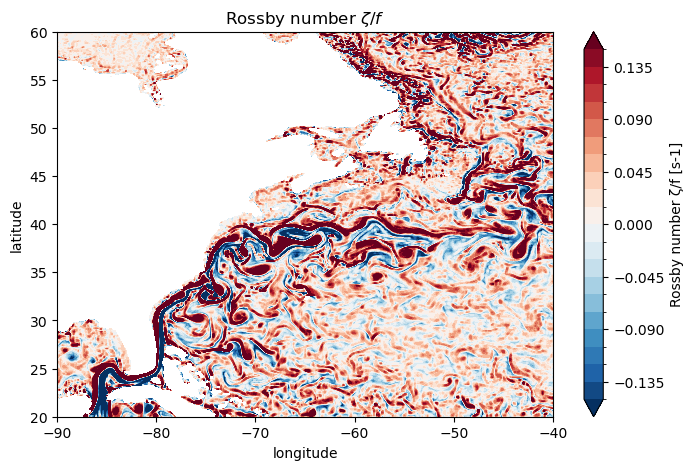

In [37]:
plt.figure(figsize=(8, 5))

Ro.plot.contourf(levels=np.linspace(-0.15, 0.15, 21),
                 cmap='RdBu_r',
                 extend='both')

plt.title(
    "Rossby number $\zeta/f$"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.xlim(-90, -40)
plt.ylim(20, 60);